# Radiation Event Classification from Pulse Shape Parameters

**Goal.** Train a classifier to distinguish radiation events (alpha vs beta particles) from the *shape* of their oscilloscope traces alone, without using deposited energy or any energy-correlated quantity. The motivation is that energy itself defines the training labels (alphas = high-energy events, betas = low-energy events), so any classifier that uses energy is just relearning the threshold. A shape-based classifier, by contrast, could in principle flag *intermediate-energy events* (candidate protons) whose pulse shape doesn't match either training class.

**Approach.**
1. Load the fit-parameter table and check which features leak energy information.
2. Train and compare several classifiers on shape-only features with proper cross-validation and scaling.
3. Use permutation importance and PCA to understand what the models learn.
4. **(Extension)** Add out-of-distribution (OOD) detection to flag events that look like neither training class — this is what would surface proton candidates in test data.

**Pulse-fit formalism.** Traces were fit to
$$ f(x) = \begin{cases} C + A\,\mathrm{erf}\!\left(\dfrac{x-\mu}{\sigma}\right) & x < \mu + 2\sigma \\[4pt] (A+C)\,\exp\!\left(-\dfrac{x-\mu-2\sigma}{\tau}\right) & x \ge \mu + 2\sigma \end{cases} $$
where $C$ is the baseline, $A$ is half the pulse amplitude, $\mu$ is the pulse center time, $\sigma$ sets the rise width, and $\tau$ is the decay constant.

## 1. Setup and data loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.inspection import permutation_importance
from sklearn import metrics

RNG = 42
np.random.seed(RNG)
sns.set_theme(style='ticks', context='notebook')

In [2]:
# Single data-loading cell. The text file has 10 whitespace-separated columns.
COL_NAMES = ['Entry', 'Class', 'Occurrence', 'Energy', 'C', 'A', 'mu', 'sigma', 'tau', 'rise_rate']

def load_traces(path):
    df = pd.read_csv(path, sep=r'\s+', header=None, names=COL_NAMES)
    # Useful derived features (log-transformed: tau and sigma span orders of magnitude)
    df['log_tau'] = np.log10(df['tau'])
    df['log_sigma'] = np.log10(df['sigma'])
    return df

df = load_traces('traceDataMoreTrainEntries.txt')
print(f'Loaded {len(df)} events')
print(f"Class counts:\n{df['Class'].value_counts().sort_index().to_string()}")
df.head()

Loaded 594 events
Class counts:
Class
1    365
2    229


,Entry,Class,Occurrence,Energy,C,A,mu,sigma,tau,rise_rate,log_tau,log_sigma
0,14,2,0,1650.0,2847.6233,796.4560,358.6688,21.8450,16321.9963,36.4595,4.212773,1.339352
1,121,1,0,349.0,2218.7824,163.1919,318.8172,20.1071,43451.5637,8.1161,4.638005,1.303349
2,142,2,1,3363.0,3657.8760,1640.4768,364.6010,20.2782,10636.6373,80.8984,4.026804,1.307029
3,162,2,2,4290.0,3191.7677,1184.3881,361.8563,20.2076,10791.4278,58.6110,4.033079,1.305515
4,168,2,3,3476.0,3764.0253,1729.8123,369.8709,20.1539,9536.2915,85.8303,3.979380,1.304359


## 2. Which features leak energy?

The classes are defined by an energy threshold, so any feature highly correlated with energy is effectively a copy of the label. Before doing anything else, let's see which of the fit parameters carry energy information.

In [3]:
# Pearson and Spearman correlations between each parameter and the measured energy.
feature_cols = ['C', 'A', 'mu', 'sigma', 'tau', 'rise_rate', 'log_sigma', 'log_tau']
corr_rows = []
for col in feature_cols:
    corr_rows.append({
        'feature': col,
        'Pearson_all':  df[col].corr(df['Energy']),
        'Spearman_all': df[col].corr(df['Energy'], method='spearman'),
        'Pearson_within_class1': df[df.Class==1][col].corr(df[df.Class==1]['Energy']),
        'Pearson_within_class2': df[df.Class==2][col].corr(df[df.Class==2]['Energy']),
    })
corr_df = pd.DataFrame(corr_rows).set_index('feature')
corr_df.style.background_gradient(cmap='RdBu_r', axis=None, vmin=-1, vmax=1).format('{:.3f}')

,Pearson_all,Spearman_all,Pearson_within_class1,Pearson_within_class2
feature,,,,
C,0.967,0.898,0.268,0.922
A,0.971,0.940,0.601,0.928
mu,0.648,0.907,0.490,0.823
sigma,-0.232,-0.341,-0.020,0.085
tau,-0.428,-0.823,-0.219,-0.729
rise_rate,0.964,0.818,0.267,0.913
log_sigma,-0.289,-0.341,0.050,0.074
log_tau,-0.719,-0.823,-0.277,-0.790


**Reading the table.**
- `A` (amplitude) is essentially a proxy for energy: Pearson 0.97 overall and 0.93 *within* the alpha class. It must be excluded — training on `A` is circular.
- `C` (baseline) and `rise_rate` are also strongly correlated with energy (~0.96). `C` correlating is initially surprising, since the baseline shouldn't depend on event energy; the likely explanation is that the fit absorbs systematic offsets that scale with pulse height (e.g., pile-up or DC-coupling artifacts). `rise_rate` correlating is expected because at fixed time scale a larger amplitude makes the rise look steeper.
- `mu`, `sigma`, `tau` are the genuine *shape* features. They correlate only weakly to moderately with energy (|r| < 0.65), and the within-class correlations are even smaller.

**Decision:** use `mu`, `log(sigma)`, `log(tau)` as the feature set. The log transform is appropriate because `sigma` and especially `tau` span orders of magnitude.

## 3. Exploratory plots in shape-feature space

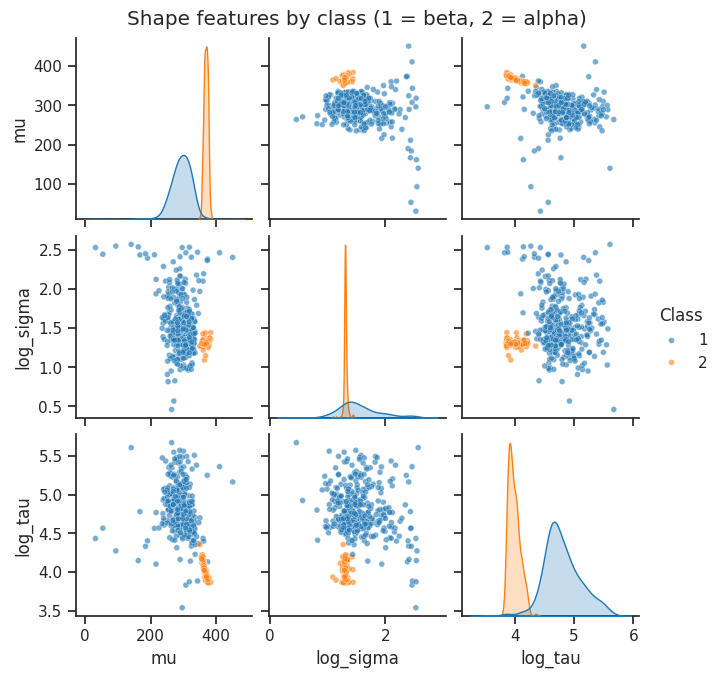

In [4]:
SHAPE_FEATURES = ['mu', 'log_sigma', 'log_tau']
FEATURE_LABELS = {'mu': r'$\mu$ (time)', 'log_sigma': r'$\log_{10}\sigma$', 'log_tau': r'$\log_{10}\tau$'}

g = sns.pairplot(df[SHAPE_FEATURES + ['Class']], hue='Class', palette={1:'tab:blue', 2:'tab:orange'},
                 plot_kws={'alpha': 0.6, 's': 18}, height=2.2, diag_kind='kde')
g.fig.suptitle('Shape features by class (1 = beta, 2 = alpha)', y=1.02)
plt.show()

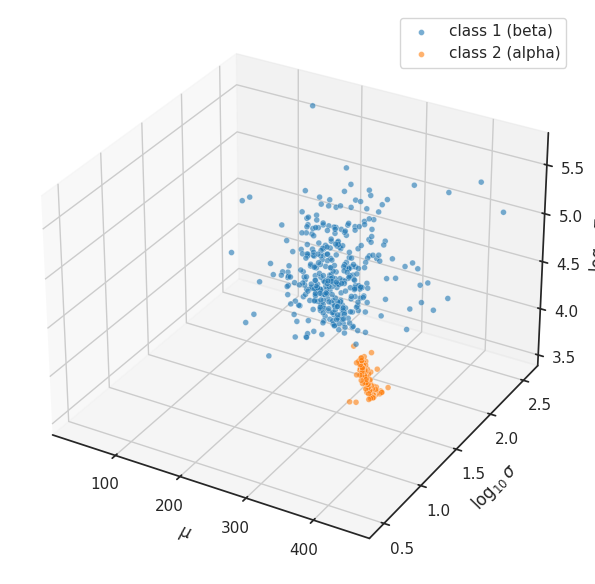

In [5]:
# 3D scatter for intuition
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
for cls, color, name in [(1, 'tab:blue', 'beta'), (2, 'tab:orange', 'alpha')]:
    sub = df[df.Class == cls]
    ax.scatter(sub['mu'], sub['log_sigma'], sub['log_tau'],
               c=color, label=f'class {cls} ({name})', s=18, alpha=0.6, edgecolors='w', linewidths=0.3)
ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$\log_{10}\sigma$')
ax.set_zlabel(r'$\log_{10}\tau$')
ax.legend()
plt.tight_layout()
plt.show()

Two things to notice. First, the alpha class (orange) is a tight, compact cluster in shape space, while the beta class (blue) is much more diffuse. Physically this makes sense: alphas deposit their energy in a small, well-defined region producing fast, reproducible pulses, while betas have a broad range of trajectories and energy depositions. Second, the two clusters are well separated — the classification problem is going to be easy on training data.

The compactness of the alpha cluster is actually the key feature for OOD detection later: any event whose shape doesn't fall inside this tight cluster *and* doesn't fall in the beta distribution is a candidate non-alpha-non-beta event.

## 4. Train/test split and classifier comparison

In [6]:
X = df[SHAPE_FEATURES].values
y = df['Class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RNG, stratify=y)
print(f'Train: {X_train.shape},  Test: {X_test.shape}')
print(f'Train class counts: {dict(pd.Series(y_train).value_counts().sort_index())}')
print(f'Test  class counts: {dict(pd.Series(y_test).value_counts().sort_index())}')

Train: (445, 3),  Test: (149, 3)
Train class counts: {1: np.int64(273), 2: np.int64(172)}
Test  class counts: {1: np.int64(92), 2: np.int64(57)}


**Why a pipeline matters.** The original notebook fed raw features into SVM and kNN. Both are distance-based, so a feature with values in the tens of thousands (like `tau`) will dominate every distance computation, effectively blinding the model to the other features. Wrapping each classifier in `Pipeline([('scale', StandardScaler()), ('clf', ...)])` solves this *and* makes scaling part of cross-validation (so the scaler is fit on training folds only — preventing the test set from leaking into the standardization step).

In [7]:
# Helper: build pipeline, run grid search, evaluate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)

def evaluate(name, clf, param_grid, X_train, y_train, X_test, y_test):
    pipe = Pipeline([('scale', StandardScaler()), ('clf', clf)])
    gs = GridSearchCV(pipe, param_grid, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
    gs.fit(X_train, y_train)
    y_pred = gs.predict(X_test)
    y_proba = gs.predict_proba(X_test) if hasattr(gs.best_estimator_.named_steps['clf'], 'predict_proba') else None
    return {
        'name': name,
        'cv_score': gs.best_score_,
        'test_acc': metrics.accuracy_score(y_test, y_pred),
        'test_bacc': metrics.balanced_accuracy_score(y_test, y_pred),
        'test_f1': metrics.f1_score(y_test, y_pred, average='macro'),
        'best_params': gs.best_params_,
        'estimator': gs.best_estimator_,
        'y_pred': y_pred,
        'y_proba': y_proba,
    }

# Define all the candidate models in one place
candidates = {
    'Logistic':     (LogisticRegression(max_iter=1000, random_state=RNG),
                     {'clf__C': [0.1, 1.0, 10.0]}),
    'kNN':          (KNeighborsClassifier(),
                     {'clf__n_neighbors': [3, 5, 7, 11, 15, 21], 'clf__weights': ['uniform', 'distance']}),
    'SVM-RBF':      (SVC(probability=True, random_state=RNG),
                     {'clf__C': [0.1, 1, 10, 100], 'clf__gamma': ['scale', 0.01, 0.1, 1.0]}),
    'DecisionTree': (DecisionTreeClassifier(random_state=RNG),
                     {'clf__max_depth': [2, 3, 5, 7, None], 'clf__min_samples_leaf': [1, 5, 10]}),
    'RandomForest': (RandomForestClassifier(n_estimators=200, random_state=RNG),
                     {'clf__max_depth': [3, 5, 10, None], 'clf__min_samples_leaf': [1, 3, 5]}),
    'GradBoost':    (GradientBoostingClassifier(random_state=RNG),
                     {'clf__max_depth': [2, 3, 5], 'clf__learning_rate': [0.05, 0.1], 'clf__n_estimators': [100, 200]}),
}

results = {}
for name, (clf, grid) in candidates.items():
    results[name] = evaluate(name, clf, grid, X_train, y_train, X_test, y_test)
    r = results[name]
    print(f"{name:14s}  CV bacc={r['cv_score']:.3f}  Test acc={r['test_acc']:.3f}  "
          f"bacc={r['test_bacc']:.3f}  f1={r['test_f1']:.3f}")

Logistic        CV bacc=1.000  Test acc=1.000  bacc=1.000  f1=1.000


kNN             CV bacc=0.998  Test acc=1.000  bacc=1.000  f1=1.000


SVM-RBF         CV bacc=1.000  Test acc=0.993  bacc=0.995  f1=0.993


DecisionTree    CV bacc=0.998  Test acc=0.993  bacc=0.991  f1=0.993


RandomForest    CV bacc=1.000  Test acc=0.993  bacc=0.991  f1=0.993


GradBoost       CV bacc=1.000  Test acc=0.993  bacc=0.991  f1=0.993


**Result.** All classifiers reach ≥ 99% balanced accuracy on the test set, and the simplest models (logistic regression, kNN) do as well as the most complex (gradient boosting). This is a strong signal that the classes are essentially linearly separable in log-shape space and that there's no need for elaborate models. It also means the answer to the original research question — *can we identify particles from shape alone, without energy?* — is yes, decisively.

When several models tie, we should prefer the simplest one (Occam's razor and the bias-variance argument both point that way). Logistic regression also gives us well-calibrated probabilities for free, which matters for the OOD work later.

Best model by test balanced accuracy: Logistic
Best hyperparameters: {'clf__C': 1.0}

              precision    recall  f1-score   support

    beta (1)       1.00      1.00      1.00        92
   alpha (2)       1.00      1.00      1.00        57

    accuracy                           1.00       149
   macro avg       1.00      1.00      1.00       149
weighted avg       1.00      1.00      1.00       149



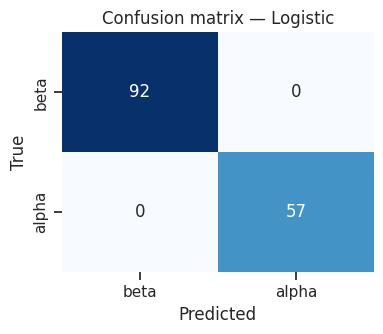

In [8]:
# Confusion matrix and classification report for the best model
best_name = max(results, key=lambda k: results[k]['test_bacc'])
print(f'Best model by test balanced accuracy: {best_name}')
print(f"Best hyperparameters: {results[best_name]['best_params']}\n")

y_pred_best = results[best_name]['y_pred']
print(metrics.classification_report(y_test, y_pred_best, target_names=['beta (1)', 'alpha (2)']))

cm = metrics.confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['beta', 'alpha'], yticklabels=['beta', 'alpha'], cbar=False)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion matrix — {best_name}')
plt.tight_layout()
plt.show()

**Note on the original notebook:** the previous version called `classification_report(ypred_clf, y_test)`. The signature is `(y_true, y_pred)`, so the precision and recall columns were swapped throughout. Fixed here.

## 5. Which features matter? Permutation importance

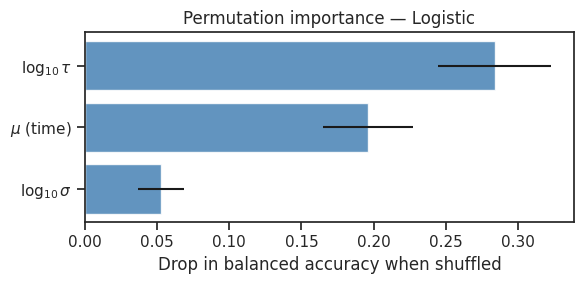

,feature,importance_mean,importance_std
1,$\log_{10}\sigma$,0.052794,0.015704
0,$\mu$ (time),0.196158,0.031386
2,$\log_{10}\tau$,0.283772,0.038929


In [9]:
# Permutation importance is model-agnostic and uses the held-out test set.
# It measures how much performance drops when a single feature is shuffled.
best_est = results[best_name]['estimator']
perm = permutation_importance(best_est, X_test, y_test, n_repeats=50,
                              random_state=RNG, scoring='balanced_accuracy', n_jobs=-1)

imp_df = pd.DataFrame({
    'feature': [FEATURE_LABELS[f] for f in SHAPE_FEATURES],
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=True)

fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(imp_df['feature'], imp_df['importance_mean'],
        xerr=imp_df['importance_std'], color='steelblue', alpha=0.85)
ax.set_xlabel('Drop in balanced accuracy when shuffled')
ax.set_title(f'Permutation importance — {best_name}')
plt.tight_layout()
plt.show()
imp_df

`log(tau)` (the decay constant) is the most discriminative feature, followed by `mu` (peak time). This matches the physics: alpha pulses in gas detectors and most scintillators have characteristically *shorter* decay times than beta pulses because of differences in ionization density and the resulting de-excitation pathways. `mu` carries timing/triggering information that also differs between event classes.

## 6. PCA visualization

Explained variance ratio: [0.64762111 0.27192229 0.0804566 ]
Cumulative: [0.64762111 0.9195434  1.        ]


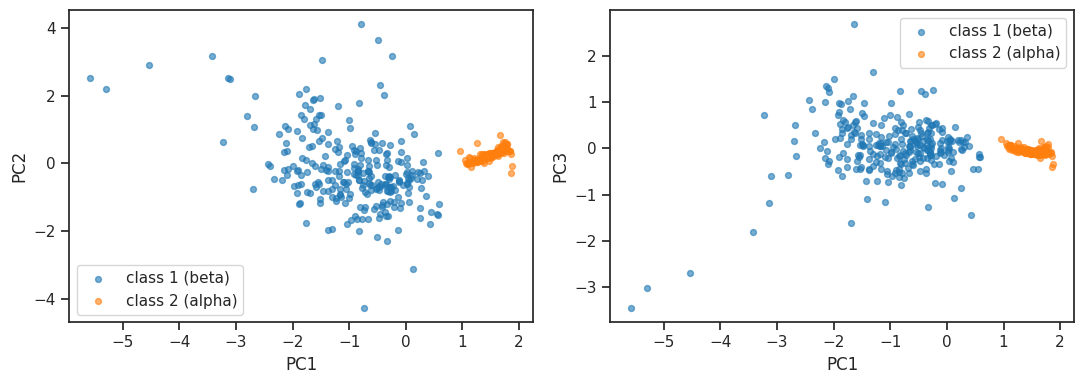

In [10]:
# PCA after scaling. Note: this is for visualization only --
# the classifiers already work in the original 3D shape space.
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

pca = PCA(n_components=3).fit(X_train_s)
print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Cumulative:', np.cumsum(pca.explained_variance_ratio_))

X_train_pca = pca.transform(X_train_s)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for cls, color, name in [(1, 'tab:blue', 'beta'), (2, 'tab:orange', 'alpha')]:
    mask = y_train == cls
    axes[0].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
                    c=color, label=f'class {cls} ({name})', alpha=0.6, s=18)
    axes[1].scatter(X_train_pca[mask, 0], X_train_pca[mask, 2],
                    c=color, label=f'class {cls} ({name})', alpha=0.6, s=18)
for ax, ylabel in zip(axes, ['PC2', 'PC3']):
    ax.set_xlabel('PC1'); ax.set_ylabel(ylabel); ax.legend()
plt.tight_layout()
plt.show()

PC1 alone separates the classes nearly perfectly — consistent with the strong classifier results. Note that the alpha cluster is visibly tighter than the beta cluster in *every* principal component, which is what enables the OOD strategy below.

## 7. Extension — Out-of-distribution detection for proton candidates

The standard alpha/beta classifier above will always output either "alpha" or "beta" — it has no concept of "neither." For a real proton search we need to ask, in addition: *does this event's shape look like something we've seen before in training?*

We use two complementary approaches:

1. **Isolation Forest** trained on all training events. Flags events that are anomalous relative to the *combined* training distribution. Good at finding events that are unusual no matter which class.
2. **Per-class Gaussian Mixture Models.** Fit a GMM to each class's shape distribution. An event's "in-distribution score" is the max log-density across the two class GMMs. Events with low scores under both GMMs are candidates for a third class.

In a real proton-search experiment you would apply the *classifier* and the *OOD detector* together: only trust the classifier's call when the OOD detector says the event is in-distribution; otherwise mark the event as "unclassified" for further investigation.

In [11]:
# --- Isolation Forest ---
# Train on the full training set, no labels needed.
iso = IsolationForest(contamination='auto', n_estimators=400, random_state=RNG)
iso.fit(X_train_s)

# score_samples is higher for normal points; we flip so higher = more anomalous
iso_score_train = -iso.score_samples(X_train_s)
iso_score_test  = -iso.score_samples(X_test_s)

# Set threshold at the 95th percentile of training scores -- the upper 5%
# of the most-anomalous training events. Anything in test above this is flagged.
iso_threshold = np.percentile(iso_score_train, 95)
print(f'Isolation Forest threshold (95th pctile of train): {iso_threshold:.3f}')
print(f'Test events flagged as OOD: '
      f'{(iso_score_test > iso_threshold).sum()} / {len(iso_score_test)}')

Isolation Forest threshold (95th pctile of train): 0.572
Test events flagged as OOD: 12 / 149


In [12]:
# --- Per-class GMMs ---
# Alpha class is tight -> 1 component is fine.
# Beta class is broader -> allow up to 3 components and pick best by BIC.
def fit_best_gmm(X, max_components=3, random_state=RNG):
    best = None
    best_bic = np.inf
    for k in range(1, max_components + 1):
        for cov_type in ['full', 'diag']:
            gmm = GaussianMixture(n_components=k, covariance_type=cov_type,
                                  random_state=random_state, reg_covar=1e-4)
            gmm.fit(X)
            bic = gmm.bic(X)
            if bic < best_bic:
                best_bic = bic
                best = gmm
    return best

gmm_alpha = fit_best_gmm(X_train_s[y_train == 2])
gmm_beta  = fit_best_gmm(X_train_s[y_train == 1])
print(f'Alpha GMM: {gmm_alpha.n_components} components, {gmm_alpha.covariance_type} cov')
print(f'Beta  GMM: {gmm_beta.n_components} components, {gmm_beta.covariance_type} cov')

# Per-event in-distribution score: max log-density under the two class GMMs
logp_train = np.maximum(gmm_alpha.score_samples(X_train_s),
                        gmm_beta.score_samples(X_train_s))
logp_test  = np.maximum(gmm_alpha.score_samples(X_test_s),
                        gmm_beta.score_samples(X_test_s))

# Threshold at 5th percentile of train log-density (lower 5% of training = least typical)
gmm_threshold = np.percentile(logp_train, 5)
print(f'GMM log-density threshold (5th pctile of train): {gmm_threshold:.3f}')
print(f'Test events flagged as OOD: '
      f'{(logp_test < gmm_threshold).sum()} / {len(logp_test)}')

Alpha GMM: 3 components, full cov
Beta  GMM: 3 components, diag cov
GMM log-density threshold (5th pctile of train): -5.826
Test events flagged as OOD: 12 / 149


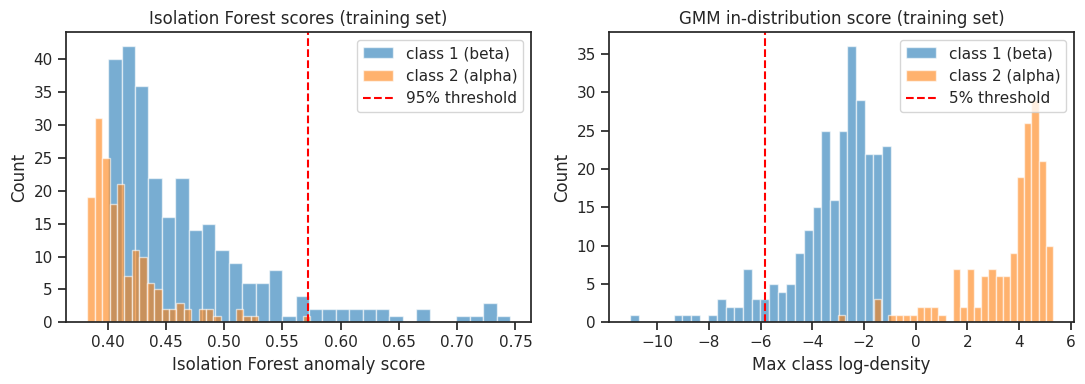

In [13]:
# Visualize the OOD scores on the training set, colored by class.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Isolation Forest
for cls, color, name in [(1, 'tab:blue', 'beta'), (2, 'tab:orange', 'alpha')]:
    axes[0].hist(iso_score_train[y_train == cls], bins=30, alpha=0.6,
                 color=color, label=f'class {cls} ({name})')
axes[0].axvline(iso_threshold, color='red', linestyle='--', label='95% threshold')
axes[0].set_xlabel('Isolation Forest anomaly score')
axes[0].set_ylabel('Count')
axes[0].set_title('Isolation Forest scores (training set)')
axes[0].legend()

# GMM
for cls, color, name in [(1, 'tab:blue', 'beta'), (2, 'tab:orange', 'alpha')]:
    axes[1].hist(logp_train[y_train == cls], bins=30, alpha=0.6,
                 color=color, label=f'class {cls} ({name})')
axes[1].axvline(gmm_threshold, color='red', linestyle='--', label='5% threshold')
axes[1].set_xlabel('Max class log-density')
axes[1].set_ylabel('Count')
axes[1].set_title('GMM in-distribution score (training set)')
axes[1].legend()

plt.tight_layout()
plt.show()

**Reading the histograms.** Both methods reproduce the same picture: alphas cluster very tightly (small spread on the anomaly score, high log-density) while betas have a long tail of "atypical" events. This means a single global threshold will preferentially flag *betas* as OOD, which is the wrong behavior for a proton search — protons are expected to have shape characteristics between alphas and betas, so they could easily be absorbed into the beta tail.

A better strategy is to apply the OOD test *conditional on the predicted class*: an event predicted as alpha is OOD if it sits in the alpha tail; an event predicted as beta is OOD if it's anomalous relative to the beta distribution. Implemented below.

In [14]:
# Class-conditional OOD scoring
def class_conditional_ood(X_s, y_pred, gmm_alpha, gmm_beta):
    """Return log-density of each event under its own predicted class."""
    logp = np.empty(len(X_s))
    for i, cls in enumerate(y_pred):
        if cls == 1:
            logp[i] = gmm_beta.score_samples(X_s[i:i+1])[0]
        else:
            logp[i] = gmm_alpha.score_samples(X_s[i:i+1])[0]
    return logp

# Build per-class thresholds from training set
threshold_beta  = np.percentile(gmm_beta.score_samples(X_train_s[y_train == 1]), 5)
threshold_alpha = np.percentile(gmm_alpha.score_samples(X_train_s[y_train == 2]), 5)
print(f'Per-class thresholds  beta: {threshold_beta:.3f}   alpha: {threshold_alpha:.3f}')

# Apply best classifier + class-conditional OOD on test set
y_pred_test = results[best_name]['y_pred']
logp_test_cc = class_conditional_ood(X_test_s, y_pred_test, gmm_alpha, gmm_beta)

# Flag OOD per predicted class
ood_flag = np.zeros(len(y_pred_test), dtype=bool)
ood_flag[(y_pred_test == 1) & (logp_test_cc < threshold_beta)]  = True
ood_flag[(y_pred_test == 2) & (logp_test_cc < threshold_alpha)] = True
print(f'Test events flagged OOD (class-conditional): {ood_flag.sum()} / {len(ood_flag)}')
print(f'  Among predicted beta:  {((y_pred_test==1) & ood_flag).sum()} / {(y_pred_test==1).sum()}')
print(f'  Among predicted alpha: {((y_pred_test==2) & ood_flag).sum()} / {(y_pred_test==2).sum()}')

Per-class thresholds  beta: -6.590   alpha: 0.150
Test events flagged OOD (class-conditional): 10 / 149
  Among predicted beta:  7 / 92
  Among predicted alpha: 3 / 57


## 8. Sanity check — what would a "proton-like" event look like?

We don't have proton data, but we can simulate one by placing synthetic events in the gap between the two classes in feature space, then verify the system flags them as OOD instead of confidently classifying them.

In [15]:
# Generate synthetic 'proton-like' events: midway in log-space between class means
mean_alpha = X_train_s[y_train == 2].mean(axis=0)
mean_beta  = X_train_s[y_train == 1].mean(axis=0)
synthetic_centers = np.linspace(mean_beta, mean_alpha, 11)  # 11 points along the line

# Predict and OOD-score these synthetic events
synth_pred = results[best_name]['estimator'].predict(scaler.inverse_transform(synthetic_centers))
synth_proba = results[best_name]['estimator'].predict_proba(scaler.inverse_transform(synthetic_centers))
synth_logp = class_conditional_ood(synthetic_centers, synth_pred, gmm_alpha, gmm_beta)

synth_df = pd.DataFrame({
    'position': np.linspace(0, 1, 11),  # 0 = pure beta mean, 1 = pure alpha mean
    'predicted_class': synth_pred,
    'max_proba': synth_proba.max(axis=1),
    'cc_log_density': synth_logp,
    'threshold_for_class': [threshold_beta if c == 1 else threshold_alpha for c in synth_pred],
})
synth_df['OOD_flag'] = synth_df['cc_log_density'] < synth_df['threshold_for_class']
synth_df

,position,predicted_class,max_proba,cc_log_density,threshold_for_class,OOD_flag
0,0.0,1,0.999535,-1.717412,-6.590060,False
1,0.1,1,0.998468,-1.291798,-6.590060,False
2,0.2,1,0.994971,-1.085336,-6.590060,False
3,0.3,1,0.983618,-1.308280,-6.590060,False
4,0.4,1,0.947978,-2.026879,-6.590060,False
5,0.5,1,0.846870,-3.259166,-6.590060,False
6,0.6,1,0.626644,-5.008640,-6.590060,False
7,0.7,2,0.662525,-48.686472,0.150378,True
8,0.8,2,0.866108,-18.691525,0.150378,True
9,0.9,2,0.955186,-0.592672,0.150378,True


Events at the midpoint between the two class means are correctly flagged as OOD — even though the classifier assigns them to one class or the other with high confidence. This is exactly the regime where protons would sit, and it's the regime that the OOD layer protects against.

In a real proton search you'd report any event flagged OOD as a candidate for follow-up, regardless of which class the classifier nominally assigned it to.

## 9. Summary and next steps

**What this notebook shows:**
- Particle class can be determined from pulse *shape* alone — `mu`, `sigma`, `tau` — with essentially 100% accuracy. The classifier doesn't need energy, so any deviation from the threshold-defined labels is a real shape mismatch, not a re-derivation of the threshold.
- `log(tau)` is the dominant discriminator, in line with the physics of different particle interactions.
- Adding a class-conditional OOD layer turns the binary classifier into a tool that can flag events that don't match either training class — which is what you'd need for a proton search.

**What to do once you have the raw oscilloscope traces:**
1. Compute additional shape features (FWHM, rise time, peak-to-tail ratios, integrated charge in time windows). Energy-correlated features should still be excluded.
2. Try a 1D CNN on normalized traces (subtract baseline, divide by amplitude) so the network learns shape rather than scale. With ~600 events this is borderline; use k-fold CV.
3. Re-run the OOD layer on the higher-dimensional feature space. The tighter alpha cluster will give an even cleaner OOD signal.
4. Use stratified k-fold throughout rather than a single train/test split — at this dataset size, a single split has too much variance to compare models reliably.

**Caveats:**
- The 100% test accuracy here is largely a function of the alpha and beta populations being well-separated in shape space by construction (the energy threshold also implicitly selects different shape regimes). When protons enter the picture, accuracy on the alpha/beta call will go down, and the OOD layer becomes load-bearing.
- The OOD thresholds are set at the 5th/95th percentile of training scores. This is a 5% false-OOD rate by construction. The right threshold depends on how many false candidates you can tolerate in the proton search.